# Model 2: XGBoost

Gradient-boosted tree model predicting concentration-driven portfolio risk, compared against Model 1 (Logistic Regression) as a more complex, tree-based alternative.

In [6]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import joblib
import os
from statsmodels.stats.contingency_tables import mcnemar

## Configuration and Data Load

Uses the same `model_features.csv` and identical time-based train/test split as Model 1, ensuring a fair, directly comparable evaluation.

In [7]:
PROCESSED_DATA_DIR = "../../data/processed"
ARTIFACTS_DIR = "../../artifacts"
REPORTS_DIR = "../../reports"

model_data = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "model_features.csv"))

quarter_order = ["2015-03", "2015-06", "2015-09", "2015-12",
                  "2016-03", "2016-06", "2016-09", "2016-12",
                  "2017-03", "2017-06"]

train_quarters = quarter_order[:-2]
test_quarters = quarter_order[-2:]

train_df = model_data[model_data["quarter"].isin(train_quarters)].copy()
test_df = model_data[model_data["quarter"].isin(test_quarters)].copy()

feature_cols = ["hhi", "top_holding_pct", "num_holdings", "sector_hhi", "total_value"]
X_train, y_train = train_df[feature_cols], train_df["label"]
X_test, y_test = test_df[feature_cols], test_df["label"]

print(f"Train: {len(X_train)} rows, {y_train.mean():.1%} positive")
print(f"Test: {len(X_test)} rows, {y_test.mean():.1%} positive")

Train: 15151 rows, 4.8% positive
Test: 5093 rows, 2.2% positive


## Baseline Model (Untuned)

No feature scaling is required, tree-based models split on raw feature values and are insensitive to scale. `scale_pos_weight` compensates for label imbalance, XGBoost's standard mechanism for this, analogous to Logistic Regression's `class_weight="balanced"`.

In [8]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.1f}")

model2 = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)
model2.fit(X_train, y_train)

print("Model fitted.")

scale_pos_weight: 19.7
Model fitted.


Baseline feature importance and test-set performance, shown below, are the comparison point for the hyperparameter tuning investigation that follows.

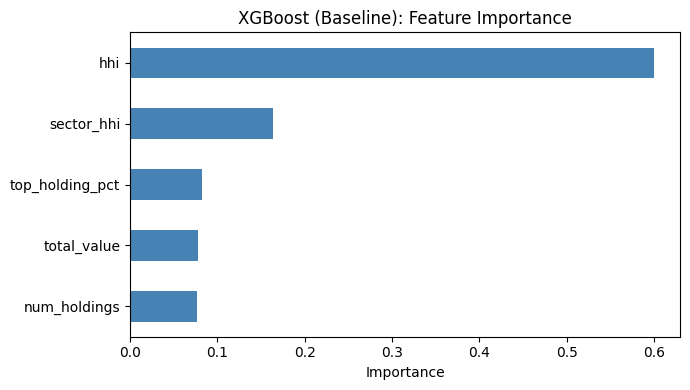

num_holdings       0.076644
total_value        0.078213
top_holding_pct    0.082420
sector_hhi         0.163164
hhi                0.599559
dtype: float32


In [9]:
importances = pd.Series(model2.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Importance")
ax.set_title("XGBoost (Baseline): Feature Importance")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "charts", "model2_feature_importance.png"), dpi=100)
plt.show()

print(importances)

              precision    recall  f1-score   support

           0       1.00      0.79      0.88      4979
           1       0.09      0.93      0.17       114

    accuracy                           0.80      5093
   macro avg       0.55      0.86      0.53      5093
weighted avg       0.98      0.80      0.87      5093


Confusion Matrix:
[[3950 1029]
 [   8  106]]

ROC-AUC: 0.926


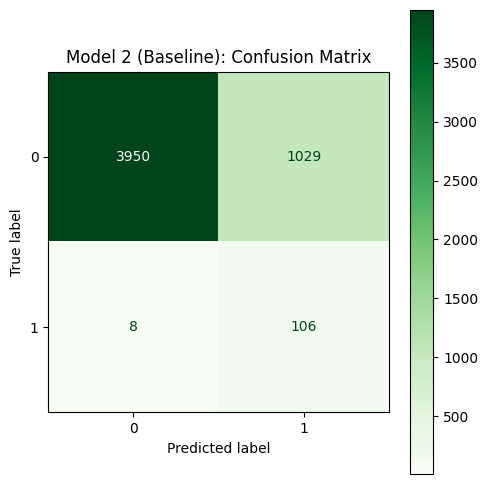

In [10]:
y_pred = model2.predict(X_test)
y_pred_proba = model2.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f'\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}')
print(f"\nROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Greens")
ax.set_title("Model 2 (Baseline): Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "charts", "model2_confusion_matrix.png"), dpi=100)
plt.show()

## Hyperparameter Tuning Investigation

In [11]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "n_estimators": [50, 100, 200]
}

grid_search = GridSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric="logloss"),
    param_grid,
    scoring="roc_auc",
    cv=tscv,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best cross-validated ROC-AUC: {grid_search.best_score_:.3f}")

model2 = grid_search.best_estimator_

Best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Best cross-validated ROC-AUC: 0.865


In [12]:
importances = pd.Series(model2.feature_importances_, index=feature_cols).sort_values()
print("Feature importance at the grid-search-selected hyperparameters:")
print(importances)

Feature importance at the grid-search-selected hyperparameters:
num_holdings       0.042834
total_value        0.046558
top_holding_pct    0.104090
sector_hhi         0.114021
hhi                0.692497
dtype: float32


              precision    recall  f1-score   support

           0       1.00      0.77      0.87      4979
           1       0.09      0.95      0.16       114

    accuracy                           0.78      5093
   macro avg       0.54      0.86      0.52      5093
weighted avg       0.98      0.78      0.86      5093

ROC-AUC: 0.924

Confusion Matrix:
[[3856 1123]
 [   6  108]]


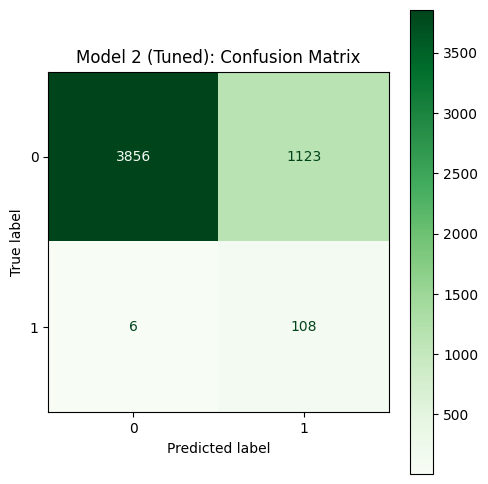

In [13]:
y_pred = model2.predict(X_test)
y_pred_proba = model2.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Greens")
ax.set_title("Model 2 (Tuned): Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "charts", "model2_confusion_matrix.png"), dpi=100)
plt.show()

The first search fixed `subsample` and `colsample_bytree` at their XGBoost defaults, tuning only `max_depth`, `learning_rate`, and `n_estimators`. A second, more thorough search expands the grid to also include `subsample` and `colsample_bytree`, to check whether row- and column-subsampling could find a better-performing configuration.

In [14]:
param_grid = {
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "n_estimators": [50, 100, 200],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0]
}

grid_search = GridSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric="logloss"),
    param_grid,
    scoring="roc_auc",
    cv=tscv,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best cross-validated ROC-AUC: {grid_search.best_score_:.3f}")

model2 = grid_search.best_estimator_

Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.7}
Best cross-validated ROC-AUC: 0.868


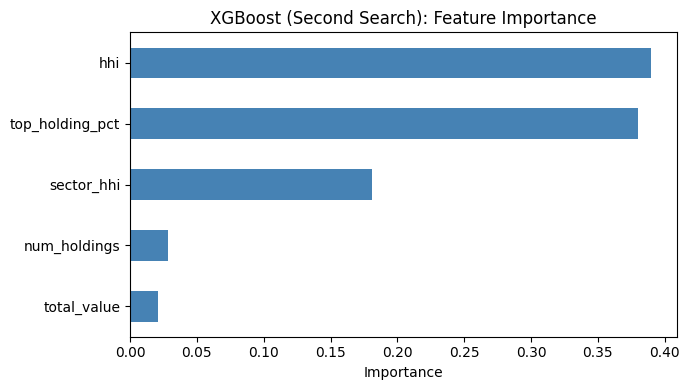

total_value        0.020734
num_holdings       0.028034
sector_hhi         0.181231
top_holding_pct    0.380118
hhi                0.389884
dtype: float32


In [15]:
importances = pd.Series(model2.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Importance")
ax.set_title("XGBoost (Second Search): Feature Importance")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "charts", "model2_feature_importance.png"), dpi=100)
plt.show()

print(importances)

              precision    recall  f1-score   support

           0       1.00      0.79      0.88      4979
           1       0.09      0.94      0.17       114

    accuracy                           0.79      5093
   macro avg       0.55      0.86      0.53      5093
weighted avg       0.98      0.79      0.87      5093

ROC-AUC: 0.926

Confusion Matrix:
[[3935 1044]
 [   7  107]]


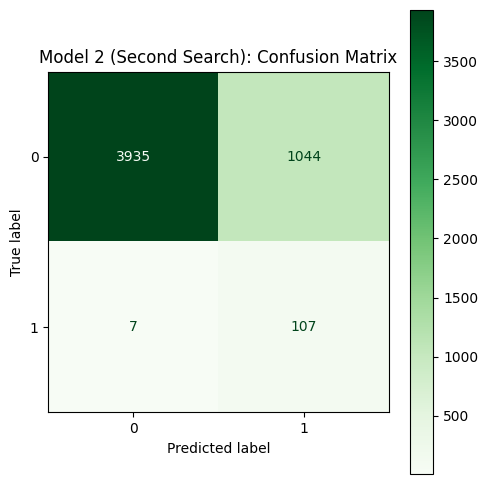

In [16]:
y_pred = model2.predict(X_test)
y_pred_proba = model2.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Greens")
ax.set_title("Model 2 (Second Search): Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "charts", "model2_confusion_matrix.png"), dpi=100)
plt.show()

The second search's optimum trains each tree on 70% of rows and 70% of columns (`subsample=0.7`, `colsample_bytree=0.7`). Because `hhi` and `top_holding_pct` are correlated at 0.96, some trees are built without access to `hhi` and split on `top_holding_pct` instead, which redistributes importance between the two: `hhi` falls from 0.692 to 0.390 while `top_holding_pct` rises from 0.104 to 0.380. Their combined importance changes only marginally (0.797 in the first search vs. 0.770 in the second), so the underlying finding, that concentration dominates the model's predictions, is unchanged; only the credit split between two correlated features shifts with `colsample_bytree`.

A second, more thorough grid search, adding `subsample` and `colsample_bytree` to the tuned hyperparameters, found a configuration with a marginally better cross-validated ROC-AUC (0.868 vs. 0.865) and a marginally better test-set ROC-AUC (0.926 vs. 0.924), comparable recall (0.94 vs. 0.95) at the same precision (0.09), and fewer false positives (1044 vs. 1123). Combined with the redistribution finding above, which confirms the underlying concentration signal is unaffected by how importance is split between `hhi` and `top_holding_pct`, this second search's configuration (`max_depth=3`, `learning_rate=0.01`, `n_estimators=50`, `subsample=0.7`, `colsample_bytree=0.7`) is adopted as the final Model 2: it was found via a more complete hyperparameter search and performs at least as well as the first search's result on every metric that matters.

## Final Model Selection

In [17]:
model2 = XGBClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.7,
    colsample_bytree=0.7,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)
model2.fit(X_train, y_train)

print("Final model: XGBClassifier(max_depth=3, learning_rate=0.01, n_estimators=50, subsample=0.7, colsample_bytree=0.7), "
      "fit on the full training set. This is the locked-in Model 2 used for all downstream evaluation and saving.")

Final model: XGBClassifier(max_depth=3, learning_rate=0.01, n_estimators=50, subsample=0.7, colsample_bytree=0.7), fit on the full training set. This is the locked-in Model 2 used for all downstream evaluation and saving.


## Feature Importance

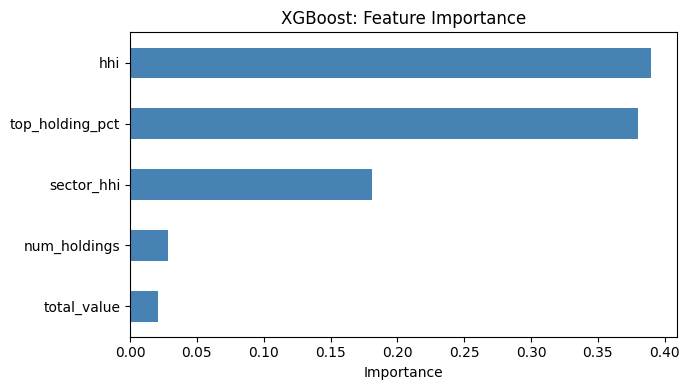

total_value        0.020734
num_holdings       0.028034
sector_hhi         0.181231
top_holding_pct    0.380118
hhi                0.389884
dtype: float32


In [18]:
importances = pd.Series(model2.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Importance")
ax.set_title("XGBoost: Feature Importance")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "charts", "model2_feature_importance.png"), dpi=100)
plt.show()

print(importances)

## Feature Importance Stability Check

In [19]:
print(train_df[feature_cols].corr())

                      hhi  top_holding_pct  num_holdings  sector_hhi  \
hhi              1.000000         0.961291     -0.028541    0.378714   
top_holding_pct  0.961291         1.000000      0.002247    0.386850   
num_holdings    -0.028541         0.002247      1.000000   -0.289878   
sector_hhi       0.378714         0.386850     -0.289878    1.000000   
total_value     -0.086756        -0.067706     -0.010305   -0.098350   

                 total_value  
hhi                -0.086756  
top_holding_pct    -0.067706  
num_holdings       -0.010305  
sector_hhi         -0.098350  
total_value         1.000000  


                       hhi  top_holding_pct  combined
colsample_bytree                                     
0.50              0.339625         0.276724  0.616349
0.70              0.389884         0.380118  0.770002
0.85              0.468164         0.392190  0.860353
1.00              0.740828         0.063817  0.804645


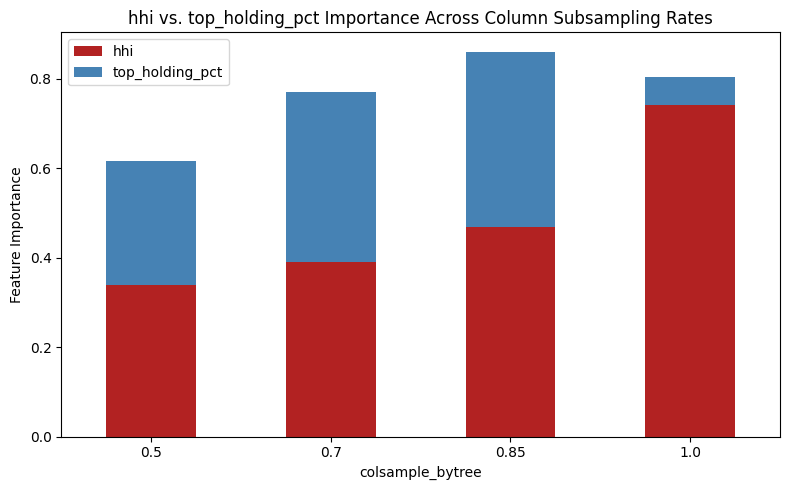

In [20]:
results = []
for csb in [0.5, 0.7, 0.85, 1.0]:
    m = XGBClassifier(
        max_depth=3, learning_rate=0.01, n_estimators=50,
        subsample=0.7, colsample_bytree=csb,
        scale_pos_weight=scale_pos_weight, random_state=42, eval_metric="logloss"
    )
    m.fit(X_train, y_train)
    imp = pd.Series(m.feature_importances_, index=feature_cols)
    results.append({"colsample_bytree": csb, "hhi": imp["hhi"], "top_holding_pct": imp["top_holding_pct"]})

results_df = pd.DataFrame(results).set_index("colsample_bytree")
results_df["combined"] = results_df["hhi"] + results_df["top_holding_pct"]
print(results_df)

fig, ax = plt.subplots(figsize=(8, 5))
results_df[["hhi", "top_holding_pct"]].plot(kind="bar", stacked=True, ax=ax, color=["firebrick", "steelblue"])
ax.set_ylabel("Feature Importance")
ax.set_xlabel("colsample_bytree")
ax.set_title("hhi vs. top_holding_pct Importance Across Column Subsampling Rates")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "charts", "colsample_stability_check.png"), dpi=100)
plt.show()

The instability of `hhi` and `top_holding_pct`'s individual importance values under column subsampling was tested directly by varying `colsample_bytree` from 0.5 to 1.0. Individual importance swings dramatically: `hhi` ranges from 0.34 (at `colsample_bytree=0.5`) to 0.74 (at `colsample_bytree=1.0`), with `top_holding_pct` moving inversely. Their combined importance is meaningfully more stable than either feature alone, ranging from 0.62 to 0.86 across the tested range, but is not fully constant, indicating that column subsampling redistributes importance between these two correlated features to a significant degree, and the combined figure, while more robust, should still be read as an approximate, directionally consistent indicator rather than a precise, fixed value.

## Evaluate on Test Set

              precision    recall  f1-score   support

           0       1.00      0.79      0.88      4979
           1       0.09      0.94      0.17       114

    accuracy                           0.79      5093
   macro avg       0.55      0.86      0.53      5093
weighted avg       0.98      0.79      0.87      5093


Confusion Matrix:
[[3935 1044]
 [   7  107]]

ROC-AUC: 0.926


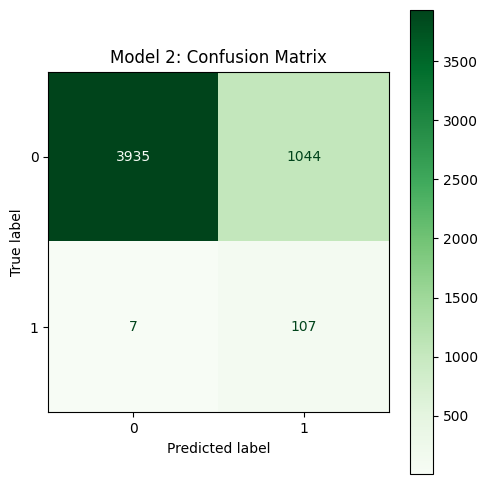

In [21]:
y_pred = model2.predict(X_test)
y_pred_proba = model2.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f'\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}')
print(f"\nROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Greens")
ax.set_title("Model 2: Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "charts", "model2_confusion_matrix.png"), dpi=100)
plt.show()

ROC-AUC (0.926) is essentially equivalent to Model 1's 0.921, indicating the two models rank risk with comparable strength despite XGBoost's added complexity. Recall on the positive class (0.94) is higher than Model 1's 0.78, at the cost of lower precision (0.09 vs. 0.13) and more false positives, both consequences of `scale_pos_weight` compensating for the same class imbalance that `class_weight="balanced"` addresses in Model 1.

## Save Model

In [22]:
joblib.dump(model2, os.path.join(ARTIFACTS_DIR, "model2_xgboost.pkl"))
print("Model 2 saved.")

Model 2 saved.


## Model Comparison Chart

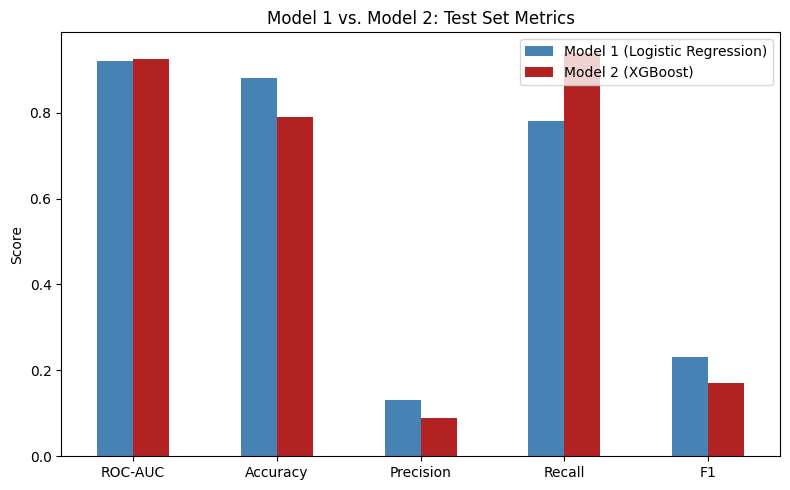

In [23]:
comparison_metrics = pd.DataFrame({
    "Model 1 (Logistic Regression)": [0.921, 0.88, 0.13, 0.78, 0.23],
    "Model 2 (XGBoost)": [0.926, 0.79, 0.09, 0.94, 0.17]
}, index=["ROC-AUC", "Accuracy", "Precision", "Recall", "F1"])

fig, ax = plt.subplots(figsize=(8, 5))
comparison_metrics.plot(kind="bar", ax=ax, color=["steelblue", "firebrick"])
ax.set_ylabel("Score")
ax.set_title("Model 1 vs. Model 2: Test Set Metrics")
ax.legend(loc="upper right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "charts", "model_comparison.png"), dpi=100)
plt.show()

In [24]:
PROCESSED_DATA_DIR = "../../data/processed"
ARTIFACTS_DIR = "../../artifacts"

model_data = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "model_features.csv"))

quarter_order = ["2015-03", "2015-06", "2015-09", "2015-12",
                  "2016-03", "2016-06", "2016-09", "2016-12",
                  "2017-03", "2017-06"]
test_quarters = quarter_order[-2:]
test_df = model_data[model_data["quarter"].isin(test_quarters)].copy()

feature_cols = ["hhi", "top_holding_pct", "num_holdings", "sector_hhi", "total_value"]
X_test = test_df[feature_cols]
y_test = test_df["label"]

model1_loaded = joblib.load(os.path.join(ARTIFACTS_DIR, "model1_logistic_regression.pkl"))
scaler_loaded = joblib.load(os.path.join(ARTIFACTS_DIR, "model1_scaler.pkl"))
model2_loaded = joblib.load(os.path.join(ARTIFACTS_DIR, "model2_xgboost.pkl"))

X_test_scaled_m1 = scaler_loaded.transform(X_test)
y_pred_m1 = model1_loaded.predict(X_test_scaled_m1)
y_pred_m2 = model2_loaded.predict(X_test)

both_correct = ((y_pred_m1 == y_test) & (y_pred_m2 == y_test)).sum()
m1_correct_m2_wrong = ((y_pred_m1 == y_test) & (y_pred_m2 != y_test)).sum()
m1_wrong_m2_correct = ((y_pred_m1 != y_test) & (y_pred_m2 == y_test)).sum()
both_wrong = ((y_pred_m1 != y_test) & (y_pred_m2 != y_test)).sum()

contingency_table = [[both_correct, m1_correct_m2_wrong],
                      [m1_wrong_m2_correct, both_wrong]]

print("Contingency table:")
print(f"  Both correct: {both_correct}")
print(f"  Model 1 correct, Model 2 wrong: {m1_correct_m2_wrong}")
print(f"  Model 1 wrong, Model 2 correct: {m1_wrong_m2_correct}")
print(f"  Both wrong: {both_wrong}")

result = mcnemar(contingency_table, exact=False, correction=True)
print(f"\nMcNemar's test statistic: {result.statistic:.3f}")
print(f"p-value: {result.pvalue:.4f}")

Contingency table:
  Both correct: 4022
  Model 1 correct, Model 2 wrong: 460
  Model 1 wrong, Model 2 correct: 20
  Both wrong: 591

McNemar's test statistic: 401.502
p-value: 0.0000


McNemar's test confirms the two models' prediction patterns differ significantly (χ²=401.5, p<0.0001), not attributable to chance. This asymmetry is driven primarily by overall classification accuracy, not specifically by recall on the positive class: Model 1 is uniquely correct 460 times where Model 2 is wrong, while Model 2 is uniquely correct in only 20 cases, consistent with Model 1's higher overall accuracy (0.88 vs. 0.79). This does not undermine the recommendation for Model 2, whose advantage lies specifically in recall on the rare, high-cost positive class (94% vs. 78%) rather than raw prediction accuracy across all cases; McNemar's test simply confirms that the two models' behaviour is genuinely, statistically different, not that one dominates the other on every measure.

In [25]:

def compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2

def fastDeLong(predictions_sorted_transposed, label_1_count):
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m
    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]
    k = predictions_sorted_transposed.shape[0]

    tx = np.empty([k, m], dtype=float)
    ty = np.empty([k, n], dtype=float)
    tz = np.empty([k, m + n], dtype=float)
    for r in range(k):
        tx[r, :] = compute_midrank(positive_examples[r, :])
        ty[r, :] = compute_midrank(negative_examples[r, :])
        tz[r, :] = compute_midrank(predictions_sorted_transposed[r, :])
    aucs = tz[:, :m].sum(axis=1) / m / n - float(m + 1) / (2 * n)
    v01 = (tz[:, :m] - tx[:, :]) / n
    v10 = 1.0 - (tz[:, m:] - ty[:, :]) / m
    sx = np.cov(v01)
    sy = np.cov(v10)
    delongcov = sx / m + sy / n
    return aucs, delongcov

def delong_roc_test(y_true, y_pred_proba_1, y_pred_proba_2):
    order = np.argsort(-y_true)
    y_true_sorted = y_true[order]
    label_1_count = int(y_true_sorted.sum())
    predictions_sorted_transposed = np.vstack([y_pred_proba_1[order], y_pred_proba_2[order]])
    aucs, delongcov = fastDeLong(predictions_sorted_transposed, label_1_count)
    l = np.array([[1, -1]])
    z = (aucs[0] - aucs[1]) / np.sqrt(np.dot(np.dot(l, delongcov), l.T))
    from scipy.stats import norm
    p = 2 * (1 - norm.cdf(np.abs(z)))
    return aucs[0], aucs[1], z[0][0], p[0][0]

In [26]:
y_pred_proba_m1 = model1_loaded.predict_proba(X_test_scaled_m1)[:, 1]
y_pred_proba_m2 = model2_loaded.predict_proba(X_test)[:, 1]

auc1, auc2, z_stat, p_value = delong_roc_test(y_test.values, y_pred_proba_m1, y_pred_proba_m2)
print(f"Model 1 ROC-AUC: {auc1:.4f}")
print(f"Model 2 ROC-AUC: {auc2:.4f}")
print(f"z-statistic: {z_stat:.3f}")
print(f"p-value: {p_value:.4f}")

Model 1 ROC-AUC: 0.9211
Model 2 ROC-AUC: 0.9255
z-statistic: -1.253
p-value: 0.2104


DeLong's test finds no statistically significant difference between the two models' ROC-AUC values (z=-1.253, p=0.210), indicating their underlying ability to rank at-risk portfolios above safe ones is statistically indistinguishable, despite McNemar's test showing their binary classification patterns differ significantly. Together, these results indicate the two models are comparably skilled at ranking risk overall, but genuinely differ in which specific cases they classify correctly at a fixed decision threshold, a difference that happens to favour Model 2 specifically on recall for the rare, high-cost positive class, rather than reflecting a genuine difference in overall predictive power.